c:\Users\USER\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[INFO] RTL font support ready. Font will be loaded based on language.
[INFO] Supported languages: Arabic, Urdu, Persian, Hebrew


PERSIAN DATASET

Dataset shape:
(8726, 10)

Dataset columns:
['Unnamed: 0', 'tweet_id', 'text', 'target', 'answer', 'target_ch', 'Violence', 'Hate', 'Vulgar', 'HateSpeech']

Cleaned dataset shape:
(8726, 10)

Class distribution:
HateSpeech
0    3860
1    4866
Name: count, dtype: int64

Training samples:
6980

Testing samples:
1746


TF-IDF

Training TF-IDF shape:
(6980, 1000)

Testing TF-IDF shape:
(1746, 1000)


TRAINING MODEL

Model training completed.


SHAP BACKGROUND

Using only 20 background samples.
c:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\shap_rtl\fonts\NotoNastaliqUrdu-Regular.ttf
[INFO] Loaded Persian font: NotoSansArabic-Regular.ttf
[INFO] Font path: c:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\fonts\NotoSansArabic-Regular.ttf
[INFO] Font display name: Noto Sans Ar

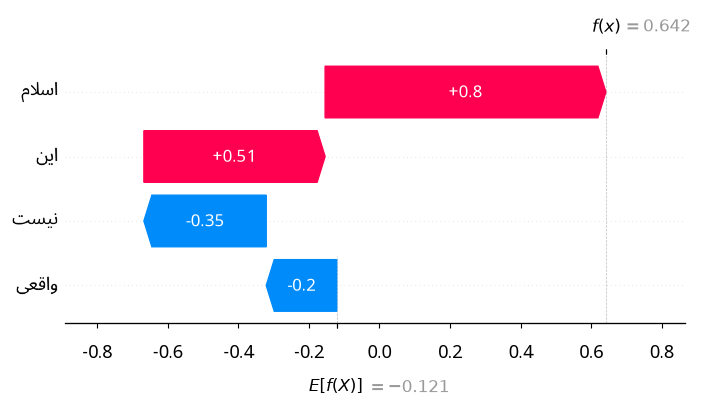


[Persian Explanation Mode]
------------------------------------------------------------------------------------------------------------------------
                                                                                                      PREDICTION: Normal
------------------------------------------------------------------------------------------------------------------------
                                                                              
Analysis of Top 1 SHAP Features (Persian)
--------------------------------------------------

Feature: ﺍﺳﻼﻡ | Value: +0.7956
----------------------------------------
ﮐﻠﻤﻪ «ﺍﺳﻼﻡ» ﺑﻪ‌ﻃﻮﺭ ﮐﻠﯽ ﺑﻪ ﺩﯾﻦ ﺗﻮﺣﯿﺪﯼ ﺍﺷﺎﺭﻩ ﺩﺍﺭﺩ ﮐﻪ ﺑﺮ ﭘﺎﯾﻪ ﺍﻋﺘﻘﺎﺩ ﺑﻪ ﺧﺪﺍﻭﻧﺪ ﯾﮑﺘﺎ ﻭ ﭘﯿﺎﻣﺒﺮ ﻣﺤﻤﺪ (ﺹ) ﺍﺳﺘﻮﺍﺭ ﺍﺳﺖ ﻭ ﺩﺭ ﺯﺑﺎﻥ ﻓﺎﺭﺳﯽ ﻣﻌﻤﻮﻻ ﺑﺮﺍﯼ ﺍﺷﺎﺭﻩ ﺑﻪ ﺍﯾﻦ ﻣﺬﻫﺐ، ﻣﻔﺎﻫﯿﻢ ﺩﯾﻨﯽ، ﻣﺮﺍﺳﻢ ﯾﺎ ﻣﺘﻮﻥ ﻣﺮﺗﺒﻂ ﺑﻪ ﮐﺎﺭ ﻣﯽ‌ﺭﻭﺩ؛ ﺩﺭ ﻧﻤﻮﻧﻪ ﺍﺭﺍﺋﻪ‌ﺷﺪﻩ ﺍﯾﻦ ﻭﺍﮊﻩ ﺻﺮﻓﺎ ﺑﻪ ﻋﻨﻮﺍﻥ ﯾﮏ ﻭﯾﮋﮔﯽ ﻣﺘﻨﯽ ﻇﺎﻫﺮ ﻣﯽ‌ﺷﻮﺩ ﻭ ﻫﯿﭻ ﺑﺎﺭ ﻣﻌﻨﺎﯾﯽ ﺧﺎﺻﯽ ﻣﺎﻧﻨﺪ ﺗﻮﻫﯿﻦ، ﺗﻤﺴﺨﺮ ﯾﺎ ﺗﺤﻘﯿﺮ ﻧﺪﺍﺭﺩ، ﺑﻠﮑﻪ ﻧﺸﺎﻥ‌ﺩﻫﻨﺪﻩ ﺣﻀﻮﺭ ﻣﺤﺘﻮﺍ ﯾﺎ ﻣﻮﺿﻮﻋ

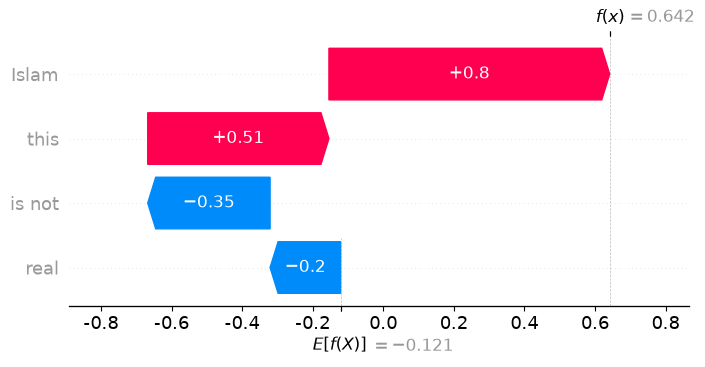


                              ENGLISH EXPLANATIONS                              

Original Persian Sample:
  ﺍﯾﻦ ﺍﺳﻼﻡ ﻭﺍﻗﻌﯽ ﻧﯿﺴﺖ ﺍﺧﻮﯼ؟!!

Translated English Sample:
  This isn’t real Islam, brother?!!
--------------------------------------------------------------------------------

[English Explanation Mode]
--------------------------------------------------------------------------------
                               PREDICTION: Normal                               
--------------------------------------------------------------------------------

Analysis of Top 1 SHAP Features (English)
--------------------------------------------------

Feature: Islam | Value: +0.7956
----------------------------------------
The term “Islam” refers to the world‑wide monotheistic religion founded on the teachings of the Prophet Muhammad, commonly used to denote the faith itself, its practices, or anything associated with Muslim believers; it is a neutral lexical item that can appear in statements of

In [1]:
# ============================================================
# PERSIAN SHAP RTL WATERFALL ANALYSIS
# Based directly on the working Urdu implementation
# ============================================================

import sys
import os
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.multiclass import OneVsRestClassifier

import warnings

warnings.filterwarnings("ignore")


# ============================================================
# SHAP RTL IMPORTS
# ============================================================

from shap_rtl.plots import waterfall
from shap_rtl import RTLSHAPExplainer


# ============================================================
# DATASET
# ============================================================

# CHANGE THIS TO YOUR PERSIAN DATASET PATH
DATA_PATH = r"C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\Datasets\PHate.csv"

df = pd.read_csv(DATA_PATH)


# ============================================================
# DISPLAY DATASET INFORMATION
# ============================================================

print("\n")
print("=" * 70)
print("PERSIAN DATASET")
print("=" * 70)

print("\nDataset shape:")
print(df.shape)

print("\nDataset columns:")
print(df.columns.tolist())


# ============================================================
# DATASET COLUMN NAMES
# ============================================================

# CHANGE THESE ONLY IF YOUR PERSIAN DATASET USES
# DIFFERENT COLUMN NAMES.

TEXT_COLUMN = "text"
LABEL_COLUMN = "HateSpeech"


# ============================================================
# CHECK REQUIRED COLUMNS
# ============================================================

if TEXT_COLUMN not in df.columns:

    raise ValueError(
        f"Text column '{TEXT_COLUMN}' was not found.\n"
        f"Available columns: {df.columns.tolist()}"
    )


if LABEL_COLUMN not in df.columns:

    raise ValueError(
        f"Label column '{LABEL_COLUMN}' was not found.\n"
        f"Available columns: {df.columns.tolist()}"
    )


# ============================================================
# CLEAN DATA
# ============================================================

df[TEXT_COLUMN] = (
    df[TEXT_COLUMN]
    .fillna("")
    .astype(str)
)

df = df[
    df[TEXT_COLUMN].str.strip() != ""
].copy()


# ============================================================
# LABEL MAPPING
# ============================================================

def map_label(x):

    if isinstance(x, str):

        x = x.strip().lower()

        # Common Persian/English textual labels
        if x in ["hate", "hateful", "hate speech", "hatespeech"]:
            return 2

        elif x in [
            "offensive",
            "offence",
            "offense"
        ]:
            return 1

        elif x in [
            "normal",
            "non-hate",
            "non_hate",
            "nonhate",
            "neutral"
        ]:
            return 0

    # Numeric labels
    try:

        x = int(float(x))

        if x == 0:
            return 0

        elif x in [1, 3]:
            return 1

        elif x in [2, 4]:
            return 2

    except:

        pass

    # Keep unknown labels unchanged for inspection
    return x


df[LABEL_COLUMN] = (
    df[LABEL_COLUMN]
    .apply(map_label)
)


# ============================================================
# REMOVE UNKNOWN LABELS
# ============================================================

df = df[
    df[LABEL_COLUMN].isin(
        [0, 1, 2]
    )
].copy()


# ============================================================
# CLASS NAMES
# ============================================================

class_names = {

    0: "Normal",

    1: "Offensive",

    2: "Hate"
}


# ============================================================
# DATASET SUMMARY
# ============================================================

print("\nCleaned dataset shape:")
print(df.shape)

print("\nClass distribution:")

print(
    df[LABEL_COLUMN]
    .value_counts()
    .sort_index()
)


# ============================================================
# TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(

    df[TEXT_COLUMN],

    df[LABEL_COLUMN],

    test_size=0.2,

    random_state=42,

    stratify=df[LABEL_COLUMN]
)


print("\nTraining samples:")
print(len(X_train))

print("\nTesting samples:")
print(len(X_test))


# ============================================================
# TF-IDF
# ============================================================

vectorizer = TfidfVectorizer(

    ngram_range=(1, 2),

    analyzer="word",

    max_features=1000,

    min_df=2,

    max_df=0.95
)


X_train_vec = vectorizer.fit_transform(
    X_train
)

X_test_vec = vectorizer.transform(
    X_test
)


print("\n")
print("=" * 70)
print("TF-IDF")
print("=" * 70)

print("\nTraining TF-IDF shape:")
print(X_train_vec.shape)

print("\nTesting TF-IDF shape:")
print(X_test_vec.shape)


# ============================================================
# MODEL
# ============================================================

model = OneVsRestClassifier(

    LogisticRegression(

        max_iter=1000,

        class_weight="balanced",

        random_state=42,

        solver="lbfgs"
    )
)


print("\n")
print("=" * 70)
print("TRAINING MODEL")
print("=" * 70)

model.fit(
    X_train_vec,
    y_train
)

print("\nModel training completed.")


# ============================================================
# SHAP BACKGROUND
# ============================================================

# IMPORTANT:
# Only a small number of training samples are used as the
# SHAP background. This makes LinearExplainer fast.

SHAP_BACKGROUND_SIZE = 20

X_background = X_train_vec[
    :SHAP_BACKGROUND_SIZE
]


masker = shap.maskers.Independent(

    data=X_background,

    max_samples=SHAP_BACKGROUND_SIZE
)


print("\n")
print("=" * 70)
print("SHAP BACKGROUND")
print("=" * 70)

print(
    f"\nUsing only {SHAP_BACKGROUND_SIZE} "
    "background samples."
)


# ============================================================
# RTL SHAP EXPLAINER
# ============================================================

explainer_rtl = RTLSHAPExplainer(

    language="Persian",

    model=model,

    vectorizer=vectorizer,

    api_type="groq"
)


# ============================================================
# TARGET PERSIAN SAMPLE
# ============================================================

sample_text = (
    "این اسلام واقعی نیست اخوی؟!!"
)


# ============================================================
# PREDICTION
# ============================================================

sample_vec = vectorizer.transform(
    [sample_text]
)


probabilities = model.predict_proba(
    sample_vec
)[0]


pred_class = int(
    np.argmax(probabilities)
)


prediction_label = class_names[
    pred_class
]


# ============================================================
# PRINT PREDICTION
# ============================================================

print("\n")
print("=" * 70)
print("PERSIAN SHAP WATERFALL ANALYSIS")
print("=" * 70)

print("\nTarget Sample:")
print(sample_text)

print("\nPrediction:")
print(prediction_label)

print("\nProbabilities:")

for class_id, probability in enumerate(
    probabilities
):

    print(
        f"{class_names[class_id]}: "
        f"{probability:.4f}"
    )


# ============================================================
# CLASS-SPECIFIC SHAP EXPLAINER
# ============================================================

class_estimator = model.estimators_[

    pred_class
]


class_explainer = shap.LinearExplainer(

    class_estimator,

    masker=masker
)


# ============================================================
# CALCULATE SHAP FOR TARGET SAMPLE
# ============================================================

print("\n")
print("=" * 70)
print("CALCULATING SHAP VALUES")
print("=" * 70)

print(
    "\nExplaining ONLY the target Persian sample."
)

shap_result = class_explainer(
    sample_vec
)

print("\nSHAP calculation completed.")


# ============================================================
# SHAP VALUES
# ============================================================

shap_values = shap_result.values[
    0
]


base_value = shap_result.base_values[
    0
]


data_values = sample_vec.toarray()[
    0
]


feature_names = np.array(
    vectorizer
    .get_feature_names_out()
)


# ============================================================
# ONLY FEATURES PRESENT IN TARGET SAMPLE
# ============================================================

present_idx = np.where(
    data_values > 0
)[0]


if len(present_idx) == 0:

    print(
        "\nERROR: No TF-IDF features found "
        "in the target Persian sample."
    )

    print(
        "\nThis means the words in the sample "
        "are not present in the learned vocabulary."
    )

    sys.exit()


# ============================================================
# SELECT TOP 7 FEATURES
# ============================================================

present_shap = shap_values[
    present_idx
]


order = np.argsort(
    np.abs(present_shap)
)[::-1]


top_n = min(
    7,
    len(order)
)


top_positions = order[
    :top_n
]


top_indices = present_idx[
    top_positions
]


top_shap = shap_values[
    top_indices
]


top_data = data_values[
    top_indices
]


top_features = feature_names[
    top_indices
]


# ============================================================
# PRINT TOP FEATURES
# ============================================================

print("\n")
print("=" * 70)
print("TOP 7 FEATURES FROM PERSIAN TARGET SAMPLE")
print("=" * 70)

for rank, (
    feature,
    value
) in enumerate(

    zip(
        top_features,
        top_shap
    ),

    start=1
):

    print(
        f"{rank}. {feature}: "
        f"{value:.6f}"
    )


# ============================================================
# CREATE WATERFALL EXPLANATION
# ============================================================

waterfall_explanation = shap.Explanation(

    values=np.asarray(
        top_shap
    ).flatten(),

    base_values=base_value,

    data=np.asarray(
        top_data
    ).flatten(),

    feature_names=list(
        top_features
    )
)


# ============================================================
# RUN PERSIAN RTL WATERFALL
# ============================================================

print("\n")
print("=" * 70)
print("RUNNING PERSIAN RTL WATERFALL")
print("=" * 70)


explainer_rtl.run_full_analysis(

    shap_values=waterfall_explanation,

    prediction_label=prediction_label,

    plot_fn=waterfall,

    sample_text=sample_text,

    max_features=7,

    allow_positive_negative_split=True
)


# ============================================================
# SHOW PLOT
# ============================================================

plt.show()


print("\n")
print("=" * 70)
print("ANALYSIS COMPLETED")
print("=" * 70)

In [2]:
# ============================================================
#  CLASSIFICATION PERFORMANCE (PERSIAN)
# ============================================================
from sklearn.metrics import (confusion_matrix, classification_report,
                             f1_score, accuracy_score)

y_train_pred = model.predict(X_train_vec)
y_test_pred  = model.predict(X_test_vec)

labels = sorted(class_names.keys())
names  = [class_names[i] for i in labels]
cm = confusion_matrix(y_test, y_test_pred, labels=labels)

print("=" * 70)
print("CONFUSION MATRIX (test set) - rows = actual, columns = predicted")
print("=" * 70)
header = "                 " + "".join(f"{n:>12}" for n in names)
print(header)
for i, name in enumerate(names):
    print(f"  actual {name:<9}" + "".join(f"{v:>12}" for v in cm[i]))

# TP/TN/FP/FN per class (one-vs-rest, since this is 3-class)
print("\n" + "=" * 70)
print("PER-CLASS TP / TN / FP / FN")
print("=" * 70)
total = cm.sum()
for i, name in enumerate(names):
    tp = cm[i, i]
    fn = cm[i, :].sum() - tp
    fp = cm[:, i].sum() - tp
    tn = total - tp - fn - fp
    print(f"  {name:<10} TP={tp:<5} TN={tn:<5} FP={fp:<5} FN={fn:<5}")

print("\n" + "=" * 70)
print("METRICS")
print("=" * 70)
print(f"  Train accuracy : {accuracy_score(y_train, y_train_pred):.4f}")
print(f"  Test accuracy  : {accuracy_score(y_test,  y_test_pred):.4f}")
print(f"  Macro F1       : {f1_score(y_test, y_test_pred, average='macro'):.4f}")
print(f"  Weighted F1    : {f1_score(y_test, y_test_pred, average='weighted'):.4f}")

print("\n" + classification_report(y_test, y_test_pred,
                                   labels=labels, target_names=names, digits=4))

majority = y_test.value_counts(normalize=True).max()
acc = accuracy_score(y_test, y_test_pred)
print(f"Majority-class baseline: {majority:.4f}")
print(f"Model beats baseline by: {acc - majority:+.4f}")

CONFUSION MATRIX (test set) - rows = actual, columns = predicted
                       Normal   Offensive        Hate
  actual Normal            575         197           0
  actual Offensive         261         713           0
  actual Hate                0           0           0

PER-CLASS TP / TN / FP / FN
  Normal     TP=575   TN=713   FP=261   FN=197  
  Offensive  TP=713   TN=575   FP=197   FN=261  
  Hate       TP=0     TN=1746  FP=0     FN=0    

METRICS
  Train accuracy : 0.7991
  Test accuracy  : 0.7377
  Macro F1       : 0.7360
  Weighted F1    : 0.7385

              precision    recall  f1-score   support

      Normal     0.6878    0.7448    0.7152       772
   Offensive     0.7835    0.7320    0.7569       974
        Hate     0.0000    0.0000    0.0000         0

    accuracy                         0.7377      1746
   macro avg     0.4904    0.4923    0.4907      1746
weighted avg     0.7412    0.7377    0.7385      1746

Majority-class baseline: 0.5578
Model beats b

In [4]:
# ============================================================
# CELL 6: EXPORT FEATURE WORDS FOR THE OCR TEST (PERSIAN)
# ============================================================
import numpy as np
from pathlib import Path

LANG = "fas"
OUT = Path(r"C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\ocr_experiment\data")
OUT.mkdir(parents=True, exist_ok=True)

print("classes  :", model.classes_)
print("estimators:", len(model.estimators_))

# Map each class to its estimator. With two classes, OneVsRestClassifier
# trains a single estimator for the positive class, so every row uses it.
if len(model.estimators_) == len(model.classes_):
    est_for = {cls: model.estimators_[i] for i, cls in enumerate(model.classes_)}
else:
    est_for = {cls: model.estimators_[0] for cls in model.classes_}
    print("Binary problem - one estimator shared across both classes.")

feature_names_arr = np.array(vectorizer.get_feature_names_out())

X = X_test_vec[:300]
keep = np.asarray(X.sum(axis=1)).ravel() > 0
X = X[keep]
print(f"\nUsing {X.shape[0]} test samples, {X.shape[1]} features")

pred = model.predict(X)
sv = np.zeros((X.shape[0], X.shape[1]), dtype=float)

for cls in model.classes_:
    idx = np.where(pred == cls)[0]
    label = class_names.get(cls, str(cls))
    if len(idx) == 0:
        print(f"  class {cls} ({label}): none predicted, skipped")
        continue
    expl = shap.LinearExplainer(est_for[cls], masker=masker)
    sv[idx] = np.asarray(expl(X[idx]).values)
    print(f"  class {cls} ({label}): {len(idx)} samples")

np.save(OUT / f"{LANG}_shap_values.npy", sv)
np.save(OUT / f"{LANG}_feature_names.npy",
        np.array(feature_names_arr, dtype=object))

print("\nsaved shape:", sv.shape)
print("saved to:", OUT.resolve())

classes  : [0 1]
estimators: 1
Binary problem - one estimator shared across both classes.

Using 300 test samples, 1000 features
  class 0 (Normal): 149 samples
  class 1 (Offensive): 151 samples

saved shape: (300, 1000)
saved to: C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\ocr_experiment\data
